##### (a)

In [1]:
from matplotlib.image import imread
import matplotlib.pyplot as plt;
import numpy as np
import os

rng = np.random.default_rng(seed=42)

In [2]:
K = 16
MAX_ITER = 30

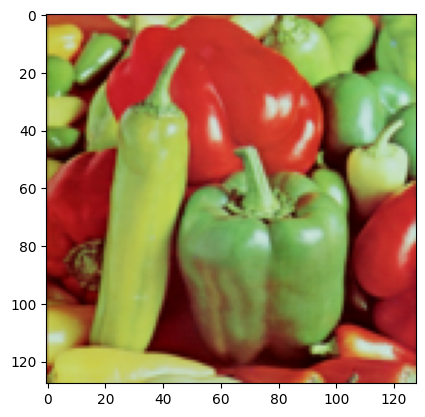

In [3]:
A = imread('data/peppers-small.tiff')
plt.imshow(A)

In [4]:
A = A.astype(float)

m, _, n = A.shape

mu = rng.choice(A.reshape(-1, n), size=K, axis=0, replace=False)
c = rng.integers(0,256, (m,m))

In [5]:
it = 0
mu_prev = np.zeros((K, 3))

while it <= MAX_ITER and not np.allclose(mu, mu_prev, atol=0.5):
    mu_prev = mu.copy()
    
    c_dist = np.sum((A[:,:,None,:]-mu[None,None,:,:])**2, axis=-1)
    c = np.argmin(c_dist, axis=-1)
    
    for k in range(K):
        mask = c==k
        if mask.any():
            mu[k] = (mask[:,:,None]*A).sum(axis=(0,1)) / mask.sum()
    
    it += 1
print(it, mu-mu_prev)

31 [[ 0.53780148  0.1599182   0.21081771]
 [ 0.03811667  0.17954086  0.06938156]
 [ 0.          0.          0.        ]
 [ 0.00831533  0.07397372  0.07195771]
 [ 0.00197787  0.0449716  -0.05841962]
 [ 0.17930819  0.04800768  0.13278326]
 [ 0.15998329  0.06131997  0.03406433]
 [-0.06996286  0.1595703   0.09788542]
 [ 0.12378641  0.00728155  0.01456311]
 [ 0.02557749 -0.00122761  0.00394564]
 [ 0.16770838  0.029305    0.04245061]
 [-0.00169408  0.02071275  0.02612546]
 [ 0.07243548  0.28770135  0.20694584]
 [ 0.29298105  0.06255402  0.02942745]
 [ 0.51626328  0.67128268  0.31178002]
 [ 0.02601908  0.10060711  0.02168257]]


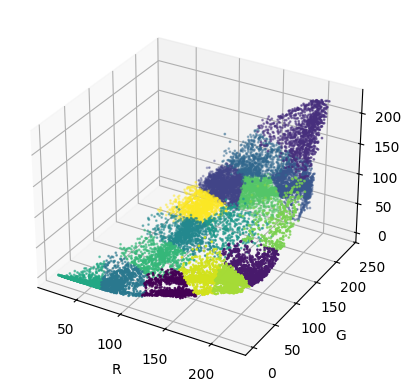

In [6]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
ax.scatter(A[:,:,0], A[:,:,1], A[:,:,2], s=1, c=c*256/K)

plt.show()

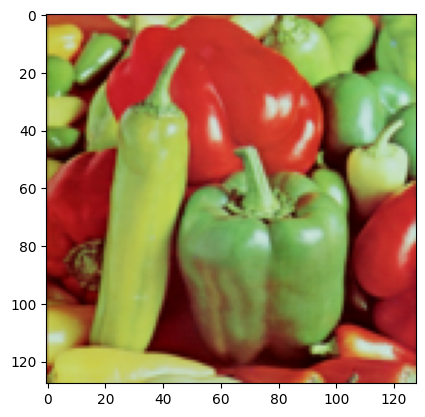

In [7]:
Ae = imread('data/peppers-small.tiff')
plt.imshow(Ae)

In [8]:
ce_dist = np.sum((Ae[:,:,None,:]-mu[None,None,:,:])**2, axis=-1)
ce = np.argmin(c_dist, axis=-1)
Aee = mu[ce].astype(int)

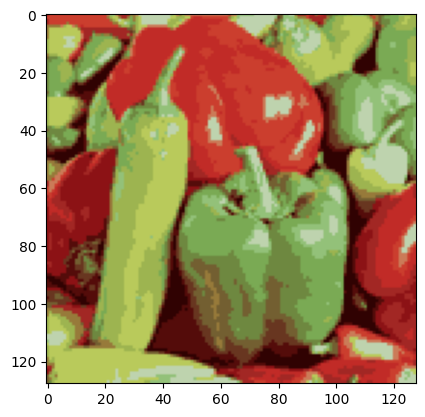

In [9]:
plt.imshow(Aee)